<a href="https://colab.research.google.com/github/elavazhagan44/AIMLMobility/blob/main/AIML_Automated_Distance_calculation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Looking in indexes: https://download.pytorch.org/whl/cu118



Running Assignment 01: Extracting Data & Tracking Metrics...

Time: 0s | Speed: 0 km/h | Accumulated Dist: 0.0 km
Time: 30s | Speed: 28 km/h | Accumulated Dist: 0.233 km
Time: 60s | Speed: 28 km/h | Accumulated Dist: 0.467 km
Time: 90s | Speed: 15 km/h | Accumulated Dist: 0.592 km
Time: 120s | Speed: 27 km/h | Accumulated Dist: 0.817 km
Time: 150s | Speed: 11 km/h | Accumulated Dist: 0.908 km
Time: 180s | Speed: 21 km/h | Accumulated Dist: 1.083 km
Time: 210s | Speed: 8 km/h | Accumulated Dist: 1.15 km
Time: 240s | Speed: 12 km/h | Accumulated Dist: 1.25 km
Time: 270s | Speed: 15 km/h | Accumulated Dist: 1.375 km
Time: 300s | Speed: 27 km/h | Accumulated Dist: 1.6 km
Time: 330s | Speed: 0 km/h | Accumulated Dist: 1.6 km
Time: 360s | Speed: 56 km/h | Accumulated Dist: 2.067 km
Time: 390s | Speed: 45 km/h | Accumulated Dist: 2.442 km
Time: 420s | Speed: 49 km/h | Accumulated Dist: 2.85 km
Time: 450s | Speed: 16 km/h | Accumulated Dist: 2.983 km
Time: 480s | Speed: 26 km/h | Accumulated 

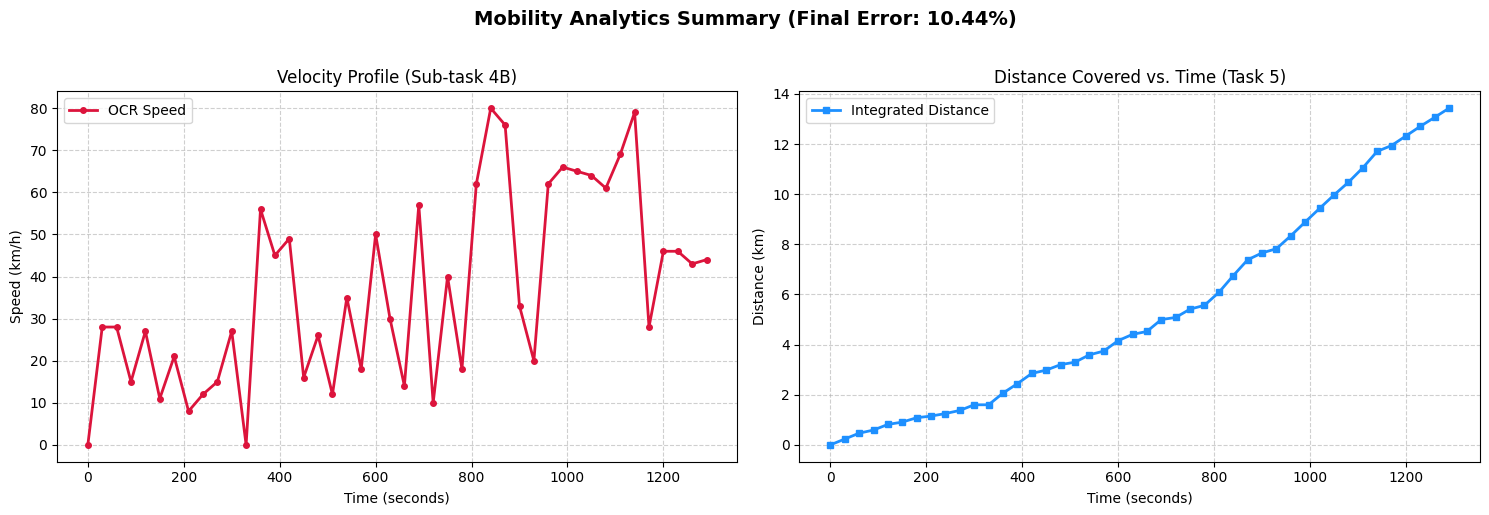


[SUCCESS] Saved report data to 'final_30s_journey_report.csv'
[SUCCESS] Saved high-resolution charts to 'mobility_metrics_plot.png'


In [5]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 2: Install Dependencies
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install easyocr

import cv2
import easyocr
import matplotlib.pyplot as plt
import os
import pandas as pd
import warnings
from google.colab.patches import cv2_imshow

warnings.filterwarnings("ignore")

# --- 1. SETUP ---
video_file = '/content/drive/MyDrive/AIMLMobility/Journey_recording.mp4'
actual_distance = 15.0  # Ground truth map distance
gap_seconds = 30        # Sub-task 4A/4B requirement

if not os.path.exists(video_file):
    print("\n" + "!"*50)
    print("CRITICAL ERROR: Video file not found!")
    print("!"*50 + "\n")
else:
    # --- 2. INITIALIZE ---
    reader = easyocr.Reader(['en'])
    cap = cv2.VideoCapture(video_file)
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    if fps == 0: fps = 30

    times, speeds, distances = [], [], []
    total_km = 0
    frame_count = 0
    last_valid_speed = 0

    print("\nRunning Assignment 01: Extracting Data & Tracking Metrics...\n")

    # --- 3. THE MAIN LOOP ---
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break

        if frame_count % (fps * gap_seconds) == 0:
            h, w, _ = frame.shape
            crop = frame[int(h*0.77):int(h*0.87), int(w*0.06):int(w*0.22)]

            gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
            _, clean_img = cv2.threshold(gray, 225, 255, cv2.THRESH_BINARY)

            results = reader.readtext(clean_img, allowlist='0123456789', detail=0)

            current_time_s = frame_count // fps
            current_speed = 0

            if len(results) > 0:
                detected = int(results[0])

                # Context Heuristic Filter
                if (detected == 65 or detected == 6 or detected == 4) and last_valid_speed < 35:
                    current_speed = 0
                elif current_time_s == 0:
                    current_speed = 0
                elif detected < 150:
                    current_speed = detected
                else:
                    current_speed = last_valid_speed
            else:
                if last_valid_speed > 45:
                    current_speed = last_valid_speed
                else:
                    current_speed = 0

            last_valid_speed = current_speed

            # Numerical Integration (Riemann Sum calculation)
            added_dist = current_speed * (gap_seconds / 3600)
            total_km = total_km + added_dist

            times.append(current_time_s)
            speeds.append(current_speed)
            distances.append(total_km)

            print(f"Time: {current_time_s}s | Speed: {current_speed} km/h | Accumulated Dist: {round(total_km, 3)} km")

        frame_count += 1

    cap.release()

    # --- 4. ERROR COMPUTATION (Task 5) ---
    final_error = (abs(actual_distance - total_km) / actual_distance) * 100

    print("\n" + "="*45)
    print(f"FINAL CALCULATED DISTANCE : {round(total_km, 3)} km")
    print(f"ACTUAL MAP DISTANCE       : {actual_distance} km")
    print(f"COMPUTED FINAL ERROR      : {round(final_error, 2)}%")
    print("="*45)

    # Save data matrix for GitHub
    df = pd.DataFrame({'Time_s': times, 'Speed_kmh': speeds, 'Distance_km': distances})
    df.to_csv('final_30s_journey_report.csv', index=False)

    # --- 5. PLOTTING PERFORMANCE METRICS (Task 5) ---
    # Create a clean, dual-subplot figure for documentation
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Graph A: Velocity vs Time
    ax1.plot(times, speeds, color='crimson', linewidth=2, marker='o', markersize=4, label='OCR Speed')
    ax1.set_title("Velocity Profile (Sub-task 4B)")
    ax1.set_xlabel("Time (seconds)")
    ax1.set_ylabel("Speed (km/h)")
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()

    # Graph B: Distance vs Time
    ax2.plot(times, distances, color='dodgerblue', linewidth=2, marker='s', markersize=4, label='Integrated Distance')
    ax2.set_title("Distance Covered vs. Time (Task 5)")
    ax2.set_xlabel("Time (seconds)")
    ax2.set_ylabel("Distance (km)")
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend()

    plt.suptitle(f"Mobility Analytics Summary (Final Error: {round(final_error, 2)}%)", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()

    # Save chart image directly for your GitHub README
    plt.savefig('mobility_metrics_plot.png', bbox_inches='tight', dpi=300)
    plt.show()

    print("\n[SUCCESS] Saved report data to 'final_30s_journey_report.csv'")
    print("[SUCCESS] Saved high-resolution charts to 'mobility_metrics_plot.png'")